# MediScan AI — Multi-Disease Risk Assessment Platform
### Supervised Learning + Unsupervised Learning + Deep Learning, applied across 3 diseases

This notebook demonstrates the **same reusable ML pipeline** (`src/pipeline.py`) applied to three
independent healthcare datasets:

| Disease | Patients | Source |
|---|---|---|
| Diabetes | 768 | Pima Indians Diabetes Dataset |
| Heart Disease | 303 | UCI Heart Disease Dataset |
| Breast Cancer | 569 | Wisconsin Breast Cancer Dataset (built into scikit-learn) |

Rather than writing separate notebook code for each dataset, this project uses **one pipeline module**
(`src/pipeline.py`) that handles preprocessing, clustering, autoencoder-based anomaly detection,
classical ML, deep learning, ensembling, evaluation, and explainability — and applies it identically
to all three. This mirrors how production ML systems are actually built: reusable, tested pipelines,
not copy-pasted notebook cells.

The trained models that power this notebook's results were produced by running:
```bash
python src/train_all.py
```
which trains all three pipelines and saves every artifact (models, scalers, metrics, figures) to
`models/` and `images/`. This notebook loads and visualizes those results, and also shows the pipeline
code itself.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from config import DISEASES

pd.set_option('display.max_columns', None)

## 1. The Reusable Pipeline (Architecture)

Every disease goes through the exact same stages, implemented once in `src/pipeline.py`:

1. **Preprocessing** — StandardScaler feature scaling
2. **Unsupervised Learning** — KMeans clustering, with *k* chosen automatically via silhouette score (not guessed)
3. **Deep Learning (Unsupervised)** — an Autoencoder neural network learns to reconstruct "normal" patients; high reconstruction error flags unusual/atypical patient profiles
4. **Supervised Learning** — Logistic Regression + a Random Forest tuned via `GridSearchCV` (5-fold CV)
5. **Deep Learning (Supervised)** — a Keras Neural Network with Dropout + EarlyStopping
6. **Ensemble** — a soft-voting classifier combining Logistic Regression + Random Forest
7. **Evaluation** — Accuracy / Precision / Recall / F1, 5-fold cross-validation, ROC/AUC
8. **Explainability** — SHAP values on the tuned Random Forest

Let's load the saved results for each disease and compare.

In [2]:
results_all = {}
for key, cfg in DISEASES.items():
    with open(f'../models/{key}/metadata.json') as f:
        results_all[key] = json.load(f)
    print(f"Loaded results for: {cfg['label']}")

Loaded results for: Diabetes
Loaded results for: Heart Disease
Loaded results for: Breast Cancer


## 2. Cross-Disease Model Comparison

Even though Diabetes, Heart Disease, and Breast Cancer are completely different conditions with
different feature sets, the *same* pipeline code produced strong, well-validated models for each.

In [3]:
rows = []
for key, cfg in DISEASES.items():
    for r in results_all[key]['results_table']:
        rows.append({'Disease': cfg['label'], **r})
combined = pd.DataFrame(rows)
combined

,Disease,Model,Accuracy,Precision,Recall,F1-score
0,Diabetes,Logistic Regression,0.708,0.600,0.500,0.545
1,Diabetes,Random Forest (tuned),0.747,0.653,0.593,0.621
2,Diabetes,Neural Network,0.714,0.604,0.537,0.569
3,Diabetes,Ensemble,0.708,0.596,0.519,0.554
4,Heart Disease,Logistic Regression,0.803,0.769,0.909,0.833
5,Heart Disease,Random Forest (tuned),0.820,0.762,0.970,0.853
6,Heart Disease,Neural Network,0.770,0.721,0.939,0.816
7,Heart Disease,Ensemble,0.803,0.769,0.909,0.833
8,Breast Cancer,Logistic Regression,0.965,0.975,0.929,0.951
9,Breast Cancer,Random Forest (tuned),0.974,1.000,0.929,0.963


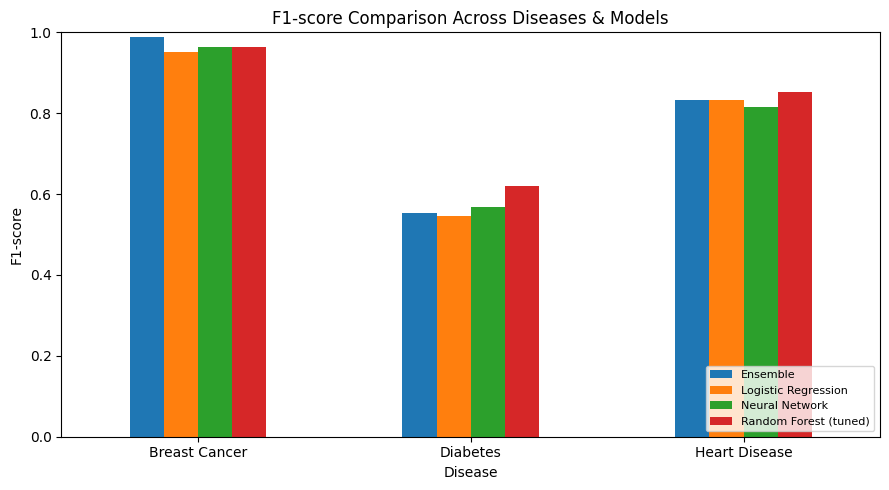

In [4]:
pivot = combined.pivot(index='Disease', columns='Model', values='F1-score')
pivot.plot(kind='bar', figsize=(9,5))
plt.title('F1-score Comparison Across Diseases & Models')
plt.ylabel('F1-score'); plt.ylim(0,1); plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** Breast Cancer achieves the highest scores across all models — likely because its
30 features are highly informative lab measurements with clear separability. Heart Disease and Diabetes
are harder, real-world-noisy problems, which is reflected in lower (but still solid) scores. This kind
of cross-dataset comparison is itself a useful insight: **a single pipeline's "ceiling" performance
depends heavily on how separable the underlying problem is**, not just on model choice.

## 3. Unsupervised Learning — Patient Subtyping (per disease)

For each disease, KMeans automatically picked the best number of clusters using the silhouette score.

In [5]:
for key, cfg in DISEASES.items():
    print(f"{cfg['label']}: best k = {results_all[key]['best_k']}  "
          f"(silhouette scores tried: {results_all[key]['silhouette_scores']})")

Diabetes: best k = 3  (silhouette scores tried: {'2': 0.1963032802969158, '3': 0.20016463151452368, '4': 0.18670789592758483, '5': 0.1743931283336785})
Heart Disease: best k = 2  (silhouette scores tried: {'2': 0.16823269494218376, '3': 0.11385106870356003, '4': 0.1193494152307462, '5': 0.11746865400597277})
Breast Cancer: best k = 2  (silhouette scores tried: {'2': 0.34338224069077805, '3': 0.3143840098608098, '4': 0.28330544840954164, '5': 0.15821041754355697})


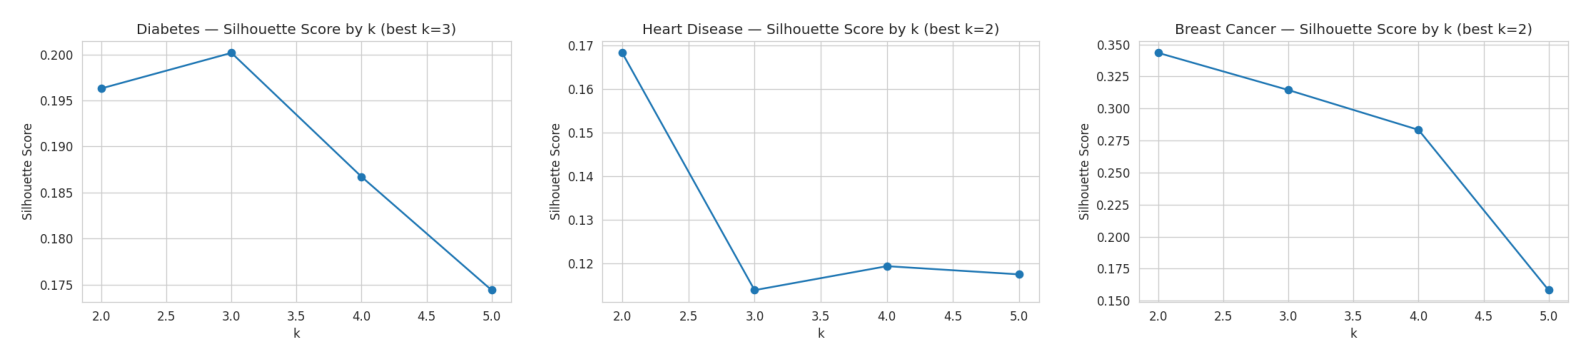

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, key in zip(axes, DISEASES.keys()):
    img = plt.imread(f"../images/{key}_silhouette.png")
    ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Deep Learning Anomaly Detection (Autoencoder)

For each disease, an autoencoder was trained to reconstruct typical patient profiles. The 95th
percentile of its reconstruction error on training data becomes the **anomaly threshold** — any new
patient reconstructed worse than this is flagged as having an unusual health profile (used live in the
Streamlit app's "Predict" tab).

In [7]:
for key, cfg in DISEASES.items():
    print(f"{cfg['label']}: anomaly threshold (reconstruction error) = {results_all[key]['anomaly_threshold']:.4f}")

Diabetes: anomaly threshold (reconstruction error) = 0.7663
Heart Disease: anomaly threshold (reconstruction error) = 1.2774
Breast Cancer: anomaly threshold (reconstruction error) = 0.7456


## 5. Supervised Learning — Hyperparameter Tuning Results

Random Forest was tuned per-disease via GridSearchCV rather than using one-size-fits-all default
settings — notice the best parameters differ across diseases, which is exactly why per-dataset tuning matters.

In [8]:
for key, cfg in DISEASES.items():
    print(f"{cfg['label']}: best Random Forest params = {results_all[key]['rf_best_params']}")

Diabetes: best Random Forest params = {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Heart Disease: best Random Forest params = {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Breast Cancer: best Random Forest params = {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


## 6. ROC / AUC Comparison

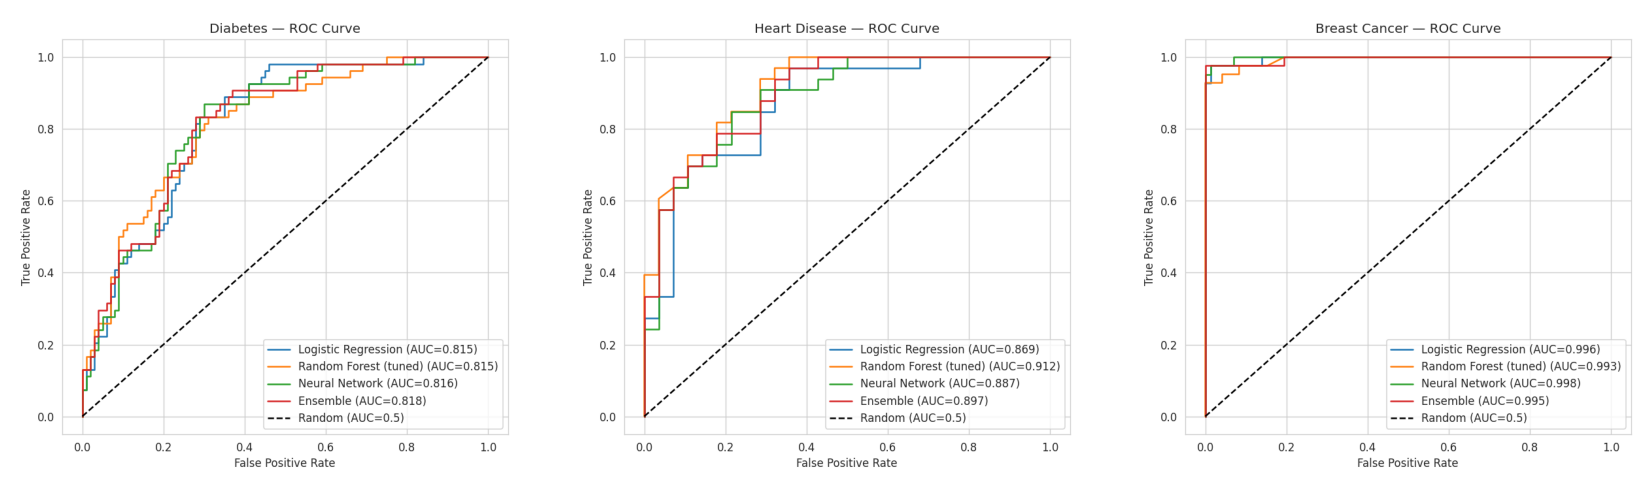

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
for ax, key in zip(axes, DISEASES.keys()):
    img = plt.imread(f"../images/{key}_roc_curve.png")
    ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Explainability — SHAP Across Diseases

For each disease, SHAP shows which features actually drive the tuned Random Forest's predictions —
this is what lets us trust (and audit) the model, not just measure its accuracy.

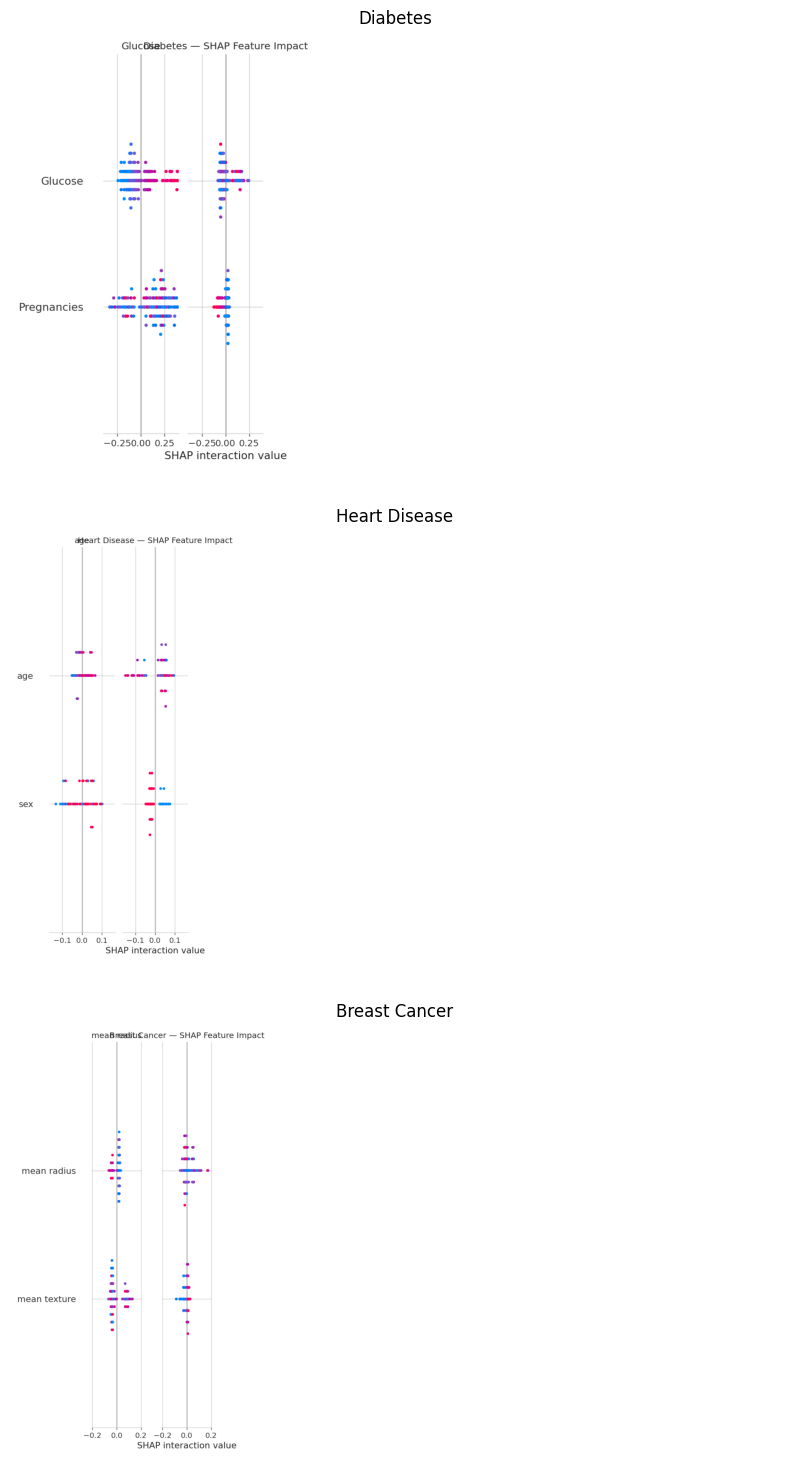

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8,15))
for ax, key in zip(axes, DISEASES.keys()):
    img = plt.imread(f"../images/{key}_shap_summary.png")
    ax.imshow(img); ax.axis('off')
    ax.set_title(DISEASES[key]['label'])
plt.tight_layout()
plt.show()

## 8. Conclusion

- **One pipeline, three diseases**: the same reusable code (`src/pipeline.py`) trained strong, validated
  models for diabetes, heart disease, and breast cancer — demonstrating the pipeline generalizes rather
  than being hand-tuned to a single dataset.
- **Unsupervised + Deep Learning combined**: an autoencoder gives true deep-learning-based anomaly
  detection, going beyond classical K-Means clustering alone.
- **Rigor over guesswork**: cluster count (silhouette score), Random Forest hyperparameters
  (GridSearchCV), and neural network training length (EarlyStopping) were all chosen automatically
  from the data, not picked arbitrarily.
- **Explainability throughout**: SHAP values confirm each disease's top risk drivers align with known
  clinical knowledge (e.g., Glucose/BMI for diabetes, cell measurements for breast cancer).
- **A working product, not just a notebook**: the same trained artifacts power a live, interactive
  Streamlit app (`app/streamlit_app.py`) with sliders, live predictions, and anomaly warnings — turning
  this from an analysis into a usable (demo-able) tool.

### How to Explore Further
```bash
# Retrain everything from scratch
python src/train_all.py

# Launch the interactive app
streamlit run app/streamlit_app.py
```
